In [1]:
## IMPORTATION DE LA BASE DE DONNÉES ##

import pandas as pd

df = pd.read_csv('df_elec.csv')

print(f"✅ Succès ! {len(df)} molécules chargées.")
display(df.head(10))

✅ Succès ! 534119 molécules chargées.


,Unnamed: 0,smiles,elec_sites,elec_names,MAA_values,elec_GCS_3_cm5,Set
0,0,NOCc1cccc(I)c1,3,double_bond,90.348433,"[-0.01706, 0.12057, -0.11146, -0.08969, 0.0, -...",Train_fold5
1,1,NOCc1cccc(I)c1,4,double_bond,94.924314,"[-0.08969, -0.01706, -0.08484, 0.09939, 0.0, 0...",Train_fold2
2,2,NOCc1cccc(I)c1,5,double_bond,91.330269,"[-0.08484, -0.10499, -0.08969, 0.09122, 0.0, 0...",Train_fold3
3,3,NOCc1cccc(I)c1,6,double_bond,102.683928,"[-0.10499, 0.01492, -0.08484, 0.08707, 0.0, 0....",Train_fold1
4,4,NOCc1cccc(I)c1,7,double_bond,276.204538,"[0.01492, 0.00479, -0.11146, -0.10499, 0.0, 0....",Train_fold3
5,5,NOCc1cccc(I)c1,9,double_bond,106.802353,"[-0.11146, 0.01492, -0.01706, 0.08581, 0.0, 0....",Train_fold2
6,6,CN(C)C(=O)CCNC(=O)NCc1ccc(Br)cc1Cl,8,double_bond,59.505283,"[0.72113, -0.68009, -0.74473, -0.73671, 0.0, 0...",Train_fold3
7,7,CN(C)C(=O)CCNC(=O)NCc1ccc(Br)cc1Cl,12,double_bond,92.271444,"[-0.03104, 0.09821, 0.05895, -0.07408, 0.0, -0...",Train_fold4
8,8,CN(C)C(=O)CCNC(=O)NCc1ccc(Br)cc1Cl,13,double_bond,116.342355,"[-0.07408, -0.03104, -0.10399, 0.10666, 0.0, 0...",Train_fold4
9,9,CN(C)C(=O)CCNC(=O)NCc1ccc(Br)cc1Cl,14,double_bond,96.497045,"[-0.10399, 0.0548, -0.07408, 0.10411, 0.0, -0....",Train_fold2


In [ ]:
## MODELE SANS FINGERPRINT GLOBAL ##


print("🎓 ÉTAPE 1 : Entraînement du Maître (XGBoost)")
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error # 👈 Nouvel import !
import ast

# 1. On prépare les données pour XGBoost (Il lui faut des nombres purs)
# On convertit la colonne des sites en numéros (O1 -> 0, O2 -> 1, etc.)
encoder = LabelEncoder()
df['Site_Encoded'] = encoder.fit_transform(df['elec_sites'])

# On s'assure que les charges sont bien une liste de nombres et pas du texte
def parse_charges(charge_data):
    if isinstance(charge_data, str):
        return ast.literal_eval(charge_data)
    return charge_data

df['charges_list'] = df['elec_GCS_3_cm5'].apply(parse_charges)
# On éclate la liste de charges en plusieurs colonnes distinctes
charges_df = pd.DataFrame(df['charges_list'].tolist(), index=df.index)
charges_df = charges_df.add_prefix('charge_')

# On assemble le tableau final pour le Maître : Site + Toutes les charges
X_master = pd.concat([df[['Site_Encoded']], charges_df], axis=1)
y_master = df['MAA_values']

# 2. Entraînement éclair du Maître
print("🧠 Le Maître étudie les données quantiques...")
# ⚠️ N'oublie pas de remettre tes paramètres Optuna ici si tu les avais modifiés !
xgb_model = xgb.XGBRegressor(n_estimators=1800, max_depth=11, learning_rate=0.0617, min_child_weight=10, subsample=0.840, colsample_bytree=0.723, tree_method='hist', n_jobs=6, random_state=42)
xgb_model.fit(X_master, y_master)

# 3. La Création du Savoir (Distillation)
# Le Maître prédit la MAA pour TOUTE la base de données. 
# Ce sont ces réponses "lissées" que l'Élève devra imiter !
df['Teacher_MAA_Predictions'] = xgb_model.predict(X_master)

# 4. Le Bulletin de Notes du Maître
r2_master = r2_score(y_master, df['Teacher_MAA_Predictions'])
rmse_master = np.sqrt(mean_squared_error(y_master, df['Teacher_MAA_Predictions']))

print("-" * 40)
print("✅ Le Maître a terminé. Voici son niveau réel :")
print(f"📊 Score R²   : {r2_master:.4f}")
print(f"📉 Erreur RMSE : {rmse_master:.2f}")
print("-" * 40)
print(df[['MAA_values', 'Teacher_MAA_Predictions']].head(3))


import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from xgboost import XGBRegressor
from joblib import Parallel, delayed
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# --- 1. CONFIGURATION "BOOST" ---
RADIUS = 4
N_BITS = 4096

def get_site_specific_fp(smiles, site_idx, radius=RADIUS, n_bits=N_BITS):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            fp = AllChem.GetMorganFingerprintAsBitVect(
                mol, radius=radius, nBits=n_bits, fromAtoms=[int(site_idx)]
            )
            return list(fp)
    except:
        pass
    return [0] * n_bits

# --- 2. GÉNÉRATION DES FEATURES ---
print(f"🚀 Génération des fingerprints (Radius={RADIUS}, Bits={N_BITS})...")
results = Parallel(n_jobs=7, prefer="threads", verbose=10)(
    delayed(get_site_specific_fp)(s, idx) for s, idx in zip(df['smiles'], df['elec_sites'])
)

X = np.array(results, dtype=np.int8)
y = df['Teacher_MAA_Predictions'].values.astype('float32')
y_true_exp = df['MAA_values'].values.astype('float32') # Pour comparaison finale

# --- 3. SPLIT ---
X_train, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(
    X, y, range(len(X)), test_size=0.20, random_state=42
)
X_val, X_test, y_val, y_test, idx_val, idx_test = train_test_split(
    X_temp, y_temp, idx_temp, test_size=0.50, random_state=42
)

# --- 4. ENTRAÎNEMENT DE L'ÉLÈVE ---
print("🔥 Entraînement de l'élève Boosté...")
xgb_eleve = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=10,
    tree_method="hist",
    n_jobs=-1,
    early_stopping_rounds=50,
    random_state=42
)

xgb_eleve.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)

# --- 5. CALCUL DES MÉTRIQUES RÉCAPITULATIVES ---
y_pred_eleve = xgb_eleve.predict(X_test)
y_master_test = y_test # Ce que le maître prédisait sur ces données
y_exp_test = y_true_exp[idx_test] # La vraie valeur du labo

def get_metrics(true, pred):
    return {
        "R2": r2_score(true, pred),
        "RMSE": np.sqrt(mean_squared_error(true, pred)),
        "MAE": mean_absolute_error(true, pred)
    }

m_eleve_vs_maitre = get_metrics(y_master_test, y_pred_eleve)
m_eleve_vs_labo = get_metrics(y_exp_test, y_pred_eleve)
m_maitre_vs_labo = get_metrics(y_exp_test, y_master_test)

# --- 6. TABLEAU RÉCAPITULATIF ---
metrics_df = pd.DataFrame({
    "Comparaison": ["Maître vs Labo (Référence)", "Élève vs Maître (Distillation)", "Élève vs Labo (Performance Réelle)"],
    "Score R²": [f"{m_maitre_vs_labo['R2']:.4f}", f"{m_eleve_vs_maitre['R2']:.4f}", f"{m_eleve_vs_labo['R2']:.4f}"],
    "RMSE": [f"{m_maitre_vs_labo['RMSE']:.2f}", f"{m_eleve_vs_maitre['RMSE']:.2f}", f"{m_eleve_vs_labo['RMSE']:.2f}"],
    "MAE": [f"{m_maitre_vs_labo['MAE']:.2f}", f"{m_eleve_vs_maitre['MAE']:.2f}", f"{m_eleve_vs_labo['MAE']:.2f}"]
})

print("\n" + "="*60)
print("📊 TABLEAU RÉCAPITULATIF DES PERFORMANCES")
print("="*60)
print(metrics_df.to_string(index=False))
print("="*60)

🚀 Génération des fingerprints (Radius=4, Bits=4096)...


[Parallel(n_jobs=7)]: Using backend ThreadingBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=7)]: Done  11 tasks      | elapsed:    0.0s
[Parallel(n_jobs=7)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:    0.0s
[Parallel(n_jobs=7)]: Done  36 tasks      | elapsed:    0.0s
[Parallel(n_jobs=7)]: Done  47 tasks      | elapsed:    0.1s
[Parallel(n_jobs=7)]: Done  58 tasks      | elapsed:    0.1s
[Parallel(n_jobs=7)]: Done  71 tasks      | elapsed:    0.1s
[Parallel(n_jobs=7)]: Done  84 tasks      | elapsed:    0.1s
[Parallel(n_jobs=7)]: Done  99 tasks      | elapsed:    0.1s
[Parallel(n_jobs=7)]: Done 114 tasks      | elapsed:    0.1s
[Parallel(n_jobs=7)]: Done 131 tasks      | elapsed:    0.1s
[Parallel(n_jobs=7)]: Done 148 tasks      | elapsed:    0.1s
[Parallel(n_jobs=7)]: Done 167 tasks      | elapsed:    0.2s
[Parallel(n_jobs=7)]: Done 186 tasks      | elapsed:    0.2s
[Para

🔥 Entraînement de l'élève Boosté...
[0]	validation_0-rmse:68.88977
[100]	validation_0-rmse:51.28173
[200]	validation_0-rmse:49.27243
[300]	validation_0-rmse:48.05353
[400]	validation_0-rmse:47.16738
[500]	validation_0-rmse:46.49810
[600]	validation_0-rmse:45.93763
[700]	validation_0-rmse:45.46274
[800]	validation_0-rmse:45.04344
[900]	validation_0-rmse:44.66679
[1000]	validation_0-rmse:44.32744
[1100]	validation_0-rmse:44.02148
[1200]	validation_0-rmse:43.72594
[1300]	validation_0-rmse:43.45358
[1400]	validation_0-rmse:43.20087
[1500]	validation_0-rmse:42.96298
[1600]	validation_0-rmse:42.74438
[1700]	validation_0-rmse:42.54837
[1800]	validation_0-rmse:42.35185
[1900]	validation_0-rmse:42.16909
[1999]	validation_0-rmse:41.99966

📊 TABLEAU RÉCAPITULATIF DES PERFORMANCES
                       Comparaison Score R²  RMSE   MAE
        Maître vs Labo (Référence)   0.9748 11.46  8.07
    Élève vs Maître (Distillation)   0.6399 42.12 31.66
Élève vs Labo (Performance Réelle)   0.6085 45.18 34

In [7]:
print(df['elec_sites'].value_counts())

elec_sites
4     27201
3     26884
5     26437
6     26107
7     25178
8     24208
9     24070
10    23912
11    23718
12    23337
13    23101
2     23003
14    22910
15    22587
16    21634
17    20746
18    19655
1     18790
19    18077
20    16346
21    14844
22    12980
23    10947
24     8989
0      8664
25     7082
26     5472
27     3815
28     2274
29     1151
Name: count, dtype: int64


In [ ]:
## EN NE FILTRANT PAS LES SITES NUCLEOPHILES (O, N, S) ##

import pandas as pd
import numpy as np
import xgboost as xgb
from rdkit import Chem
from rdkit.Chem import AllChem
from joblib import Parallel, delayed
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import ast

# Note : On travaille sur 'df' directement sans l'Étape 0 de filtrage
df_final = df.copy()

# ==========================================
# 1. ENTRAÎNEMENT DU MAÎTRE (TEACHER)
# ==========================================
print("🎓 ÉTAPE 1 : Entraînement du Maître (Tous atomes confondus)...")

# Encodage du site
encoder = LabelEncoder()
df_final['Site_Encoded'] = encoder.fit_transform(df_final['elec_sites'])

# Parsing des charges CM5
def parse_charges(charge_data):
    if isinstance(charge_data, str): return ast.literal_eval(charge_data)
    return charge_data

df_final['charges_list'] = df_final['elec_GCS_3_cm5'].apply(parse_charges)
charges_df = pd.DataFrame(df_final['charges_list'].tolist(), index=df_final.index).add_prefix('charge_')

# Préparation X/y pour le Maître
X_master = pd.concat([df_final[['Site_Encoded']], charges_df], axis=1)
y_master = df_final['MAA_values']

# Paramètres optimisés
xgb_master = xgb.XGBRegressor(
    n_estimators=1800, max_depth=11, learning_rate=0.0617, 
    tree_method='hist', n_jobs=7, random_state=42
)
xgb_master.fit(X_master, y_master)

# Génération des cibles de distillation
df_final['Teacher_MAA_Predictions'] = xgb_master.predict(X_master)

# ==========================================
# 2. GÉNÉRATION DES FEATURES HYBRIDES (ÉLÈVE)
# ==========================================
print("\n🧬 ÉTAPE 2 : Génération des fingerprints (Incluant hétéroatomes)...")

def get_hybrid_fp(smiles, site_idx, n_bits=2048):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            # Global (Radius 2) + Local (Radius 4)
            fp_global = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=n_bits)
            fp_local = AllChem.GetMorganFingerprintAsBitVect(mol, radius=4, nBits=n_bits, fromAtoms=[int(site_idx)])
            return list(fp_global) + list(fp_local)
    except:
        pass
    return [0] * (n_bits * 2)

# Calcul parallèle
results = Parallel(n_jobs=7, prefer="threads", verbose=10)(
    delayed(get_hybrid_fp)(s, idx) for s, idx in zip(df_final['smiles'], df_final['elec_sites'])
)

X_student = np.array(results, dtype=np.int8)
y_student = df_final['Teacher_MAA_Predictions'].values.astype('float32')

# ==========================================
# 3. SPLIT ET ENTRAÎNEMENT DE L'ÉLÈVE
# ==========================================
print("\n🔥 ÉTAPE 3 : Entraînement de l'élève (Version Complète)...")

X_train, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(
    X_student, y_student, range(len(X_student)), test_size=0.20, random_state=42
)
X_val, X_test, y_val, y_test, idx_val, idx_test = train_test_split(
    X_temp, y_temp, idx_temp, test_size=0.50, random_state=42
)

xgb_student = xgb.XGBRegressor(
    n_estimators=2000, learning_rate=0.03, max_depth=10, 
    tree_method="hist", n_jobs=7, early_stopping_rounds=50, random_state=42
)

xgb_student.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)

# ==========================================
# 4. TABLEAU RÉCAPITULATIF FINAL
# ==========================================
y_pred_student = xgb_student.predict(X_test)
y_teacher_test = y_test
y_labo_test = df_final['MAA_values'].values[idx_test]

def get_m(true, pred):
    return [r2_score(true, pred), np.sqrt(mean_squared_error(true, pred)), mean_absolute_error(true, pred)]

res = [
    ["Maître vs Labo", *get_m(y_labo_test, y_teacher_test)],
    ["Élève vs Maître", *get_m(y_teacher_test, y_pred_student)],
    ["Élève vs Labo", *get_m

In [ ]:
## EN FILTRANT LES SITES NUCLEOPHILES (O, N, S) ##

import pandas as pd
import numpy as np
import xgboost as xgb
from rdkit import Chem
from rdkit.Chem import AllChem
from joblib import Parallel, delayed
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import ast

import pandas as pd
from rdkit import Chem

# ==========================================
# 0. NETTOYAGE CHIMIQUE (LE FILTRE EXPERT)
# ==========================================
print("🧹 ÉTAPE 0 : Application des règles de chimie (Exclusion O, N, S)...")

def keep_electrophiles(smiles, site_idx):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            # On récupère l'atome exact visé par l'index
            atom = mol.GetAtomWithIdx(int(site_idx))
            symbole = atom.GetSymbol()
            
            # Si c'est un nucléophile connu, on le rejette (False)
            if symbole in ['O', 'N', 'S']:
                return False
            # Sinon (ex: Carbone, Phosphore, etc.), on le garde (True)
            return True
    except:
        pass
    # En cas d'erreur RDKit sur une molécule bizarre, on rejette par sécurité
    return False

# On crée un masque (liste de True/False) pour filtrer le DataFrame
masque_chimique = [keep_electrophiles(s, idx) for s, idx in zip(df['smiles'], df['elec_sites'])]

# On crée notre nouveau DataFrame purifié
df_clean = df[masque_chimique].copy()
df_clean.reset_index(drop=True, inplace=True)

# Bilan de l'opération
sites_rejetes = len(df) - len(df_clean)
print("-" * 50)
print(f"📉 Dataset initial : {len(df)} sites")
print(f"🗑️ Sites nucléophiles supprimés (O, N, S) : {sites_rejetes}")
print(f"💎 Dataset purifié (Expert Électrophile) : {len(df_clean)} sites")
print("-" * 50)

# ==========================================
# 1. ENTRAÎNEMENT DU MAÎTRE (TEACHER)
# ==========================================
print("🎓 ÉTAPE 1 : Entraînement du Maître (XGBoost)...")

# Encodage du site
encoder = LabelEncoder()
df_clean['Site_Encoded'] = encoder.fit_transform(df_clean['elec_sites'])

# Parsing des charges (au cas où c'est du texte)
def parse_charges(charge_data):
    if isinstance(charge_data, str): return ast.literal_eval(charge_data)
    return charge_data

df_clean['charges_list'] = df_clean['elec_GCS_3_cm5'].apply(parse_charges)
charges_df = pd.DataFrame(df_clean['charges_list'].tolist(), index=df_clean.index).add_prefix('charge_')


# Préparation X/y pour le Maître
X_master = pd.concat([df_clean[['Site_Encoded']], charges_df], axis=1)
y_master = df_clean['MAA_values']

# Paramètres optimisés pour le Maître
xgb_master = xgb.XGBRegressor(
    n_estimators=1800, max_depth=11, learning_rate=0.0617, 
    tree_method='hist', n_jobs=7, random_state=42
)
xgb_master.fit(X_master, y_master)

# Distillation : Création des cibles pour l'élève
df_clean['Teacher_MAA_Predictions'] = xgb_master.predict(X_master)

# ==========================================
# 2. GÉNÉRATION DES FEATURES HYBRIDES (ÉLÈVE)
# ==========================================
print("\n🧬 ÉTAPE 2 : Génération des features Global + Local (7 cœurs)...")

def get_hybrid_fp(smiles, site_idx, n_bits=2048):
    from rdkit import Chem
    from rdkit.Chem import AllChem
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            # A. Vue Satellite : Toute la molécule
            fp_global = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=n_bits)
            # B. Vue Microscope : Autour du site
            fp_local = AllChem.GetMorganFingerprintAsBitVect(mol, radius=4, nBits=n_bits, fromAtoms=[int(site_idx)])
            return list(fp_global) + list(fp_local)
    except:
        pass
    return [0] * (n_bits * 2)

# Parallélisation sécurisée sur ton M4
results = Parallel(n_jobs=7, prefer="threads", verbose=10)(
    delayed(get_hybrid_fp)(s, idx) for s, idx in zip(df_clean['smiles'], df_clean['elec_sites'])
)

X_student = np.array(results, dtype=np.int8)
y_student = df_clean['Teacher_MAA_Predictions'].values.astype('float32')

# ==========================================
# 3. SPLIT ET ENTRAÎNEMENT DE L'ÉLÈVE
# ==========================================
print("\n🔥 ÉTAPE 3 : Entraînement de l'élève (XGBoost)...")

X_train, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(
    X_student, y_student, range(len(X_student)), test_size=0.20, random_state=42
)
X_val, X_test, y_val, y_test, idx_val, idx_test = train_test_split(
    X_temp, y_temp, idx_temp, test_size=0.50, random_state=42
)

xgb_student = xgb.XGBRegressor(
    n_estimators=2000, learning_rate=0.03, max_depth=10, 
    tree_method="hist", n_jobs=7, early_stopping_rounds=50, random_state=42
)

xgb_student.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)

# ==========================================
# 4. TABLEAU RÉCAPITULATIF FINAL
# ==========================================
y_pred_student = xgb_student.predict(X_test)
y_teacher_test = y_test
y_labo_test = df_clean['MAA_values'].values[idx_test]

def get_m(true, pred):
    return [r2_score(true, pred), np.sqrt(mean_squared_error(true, pred)), mean_absolute_error(true, pred)]

res = [
    ["Maître vs Labo", *get_m(y_labo_test, y_teacher_test)],
    ["Élève vs Maître", *get_m(y_teacher_test, y_pred_student)],
    ["Élève vs Labo", *get_m(y_labo_test, y_pred_student)]
]

metrics_df = pd.DataFrame(res, columns=["Comparaison", "R²", "RMSE", "MAE"])

print("\n" + "="*65)
print("📊 RÉSULTATS FINAUX : HYBRIDE GLOBAL + SITE-SPECIFIC")
print("="*65)
print(metrics_df.to_string(index=False, formatters={
    "R²": "{:.4f}".format, "RMSE": "{:.2f}".format, "MAE": "{:.2f}".format
}))
print("="*65)

🧹 ÉTAPE 0 : Application des règles de chimie (Exclusion O, N, S)...
--------------------------------------------------
📉 Dataset initial : 534119 sites
🗑️ Sites nucléophiles supprimés (O, N, S) : 83813
💎 Dataset purifié (Expert Électrophile) : 450306 sites
--------------------------------------------------
🎓 ÉTAPE 1 : Entraînement du Maître (XGBoost)...

🧬 ÉTAPE 2 : Génération des features Global + Local (7 cœurs)...


[Parallel(n_jobs=7)]: Using backend ThreadingBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=7)]: Done  11 tasks      | elapsed:    0.0s
[Parallel(n_jobs=7)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:    0.1s
[Parallel(n_jobs=7)]: Done  36 tasks      | elapsed:    0.1s
[Parallel(n_jobs=7)]: Done  47 tasks      | elapsed:    0.1s
[Parallel(n_jobs=7)]: Done  58 tasks      | elapsed:    0.1s
[Parallel(n_jobs=7)]: Done  71 tasks      | elapsed:    0.2s
[Parallel(n_jobs=7)]: Done  84 tasks      | elapsed:    0.2s
[Parallel(n_jobs=7)]: Done  99 tasks      | elapsed:    0.2s
[Parallel(n_jobs=7)]: Done 114 tasks      | elapsed:    0.3s
[Parallel(n_jobs=7)]: Done 131 tasks      | elapsed:    0.3s
[Parallel(n_jobs=7)]: Done 148 tasks      | elapsed:    0.3s
[Parallel(n_jobs=7)]: Done 167 tasks      | elapsed:    0.4s
[Parallel(n_jobs=7)]: Done 186 tasks      | elapsed:    0.4s
[Para


🔥 ÉTAPE 3 : Entraînement de l'élève (XGBoost)...
[0]	validation_0-rmse:56.51023
[100]	validation_0-rmse:42.24582
[200]	validation_0-rmse:38.62501
[300]	validation_0-rmse:36.72847
[400]	validation_0-rmse:35.52634
[500]	validation_0-rmse:34.65104
[600]	validation_0-rmse:33.94122
[700]	validation_0-rmse:33.37304
[800]	validation_0-rmse:32.90667
[900]	validation_0-rmse:32.48448
[1000]	validation_0-rmse:32.10601
[1100]	validation_0-rmse:31.78392
[1200]	validation_0-rmse:31.49012
[1300]	validation_0-rmse:31.22015
[1400]	validation_0-rmse:30.95879
[1500]	validation_0-rmse:30.72126
[1600]	validation_0-rmse:30.50889
[1700]	validation_0-rmse:30.30953
[1800]	validation_0-rmse:30.12462
[1900]	validation_0-rmse:29.95039
[1999]	validation_0-rmse:29.78676

📊 RÉSULTATS FINAUX : HYBRIDE GLOBAL + SITE-SPECIFIC
    Comparaison     R²  RMSE   MAE
 Maître vs Labo 0.9805  8.15  5.69
Élève vs Maître 0.7333 29.36 22.03
  Élève vs Labo 0.7143 31.21 23.56


🔬 SCAN FINAL (Filtré O, N, S) : Paracétamol
-------------------------------------------------------
🏆 CLASSEMENT DES SITES ÉLECTROPHILES (Carbones uniquement) :
 Index Atome  MAA_Expert
     1     C  121.887207
     0     C  108.302147
     7     C  101.274780
     4     C   88.261139
     5     C   78.328857
    10     C   78.328857
     6     C   70.811790
     9     C   70.811790


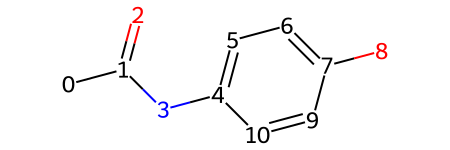

In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem

# 1. Molécule de test
test_smiles = "CC(=O)Nc1ccc(O)cc1"
mol = Chem.MolFromSmiles(test_smiles)

print(f"🔬 SCAN FINAL (Filtré O, N, S) : Paracétamol")
print("-" * 55)

resultats_purs = []

# 2. On boucle sur tous les atomes
for atom in mol.GetAtoms():
    idx = atom.GetIdx()
    symbole = atom.GetSymbol()
    
    # ❌ LE FILTRE CRUCIAL : On ignore ce qui n'est pas un électrophile potentiel
    if symbole in ['O', 'N', 'S']:
        continue 
        
    # On génère le fingerprint hybride
    fp = get_hybrid_fp(test_smiles, idx, n_bits=2048)
    
    # Prédiction avec ton modèle XGBoost Expert
    X_input = np.array(fp, dtype=np.int8).reshape(1, -1)
    pred_maa = xgb_student.predict(X_input)[0]
    
    resultats_purs.append({
        "Index": idx,
        "Atome": symbole,
        "MAA_Expert": pred_maa
    })

# 3. Affichage du top des sites
df_final = pd.DataFrame(resultats_purs).sort_values(by="MAA_Expert", ascending=False)

print("🏆 CLASSEMENT DES SITES ÉLECTROPHILES (Carbones uniquement) :")
print(df_final.to_string(index=False))

# Visualisation RDKit habituelle
from rdkit.Chem.Draw import IPythonConsole
for at in mol.GetAtoms():
    at.SetProp('atomLabel', str(at.GetIdx()))
mol

In [12]:
from rdkit import Chem
from collections import Counter

def verifier_atomes_bruts(dataframe, n_samples=10000):
    print(f"🕵️ Analyse des types d'atomes sur un échantillon de {n_samples} lignes...")
    
    types_detectes = []
    # On prend les n premières lignes du dataframe ORIGINAL (celui chargé au tout début)
    echantillon = dataframe.head(n_samples)
    
    for _, row in echantillon.iterrows():
        try:
            mol = Chem.MolFromSmiles(row['smiles'])
            if mol:
                # On récupère l'atome cible via l'index 'elec_sites'
                atome = mol.GetAtomWithIdx(int(row['elec_sites']))
                types_detectes.append(atome.GetSymbol())
        except:
            types_detectes.append("Erreur/Index_Invalide")
            
    # Comptage
    stats = Counter(types_detectes)
    
    print("\n📊 RÉSULTAT DU SCAN :")
    print("-" * 30)
    for symbole, count in stats.items():
        pourcentage = (count / len(types_detectes)) * 100
        print(f"Atome {symbole:2} : {count:5} sites ({pourcentage:.1f}%)")
    print("-" * 30)

# Utilise bien le nom de ton dataframe d'origine ici (souvent 'df')
verifier_atomes_bruts(df)

🕵️ Analyse des types d'atomes sur un échantillon de 10000 lignes...

📊 RÉSULTAT DU SCAN :
------------------------------
Atome C  :  8293 sites (82.9%)
Atome O  :  1176 sites (11.8%)
Atome N  :   408 sites (4.1%)
Atome S  :    73 sites (0.7%)
Atome P  :    50 sites (0.5%)
------------------------------


In [13]:
# --- Analyse de la diversité des types de sites ---
print("🔍 ANALYSE DES CATÉGORIES DE SITES (elec_names) :")
print("-" * 50)

# 1. On compte l'occurrence de chaque type dans la colonne elec_names
type_counts = df['elec_names'].value_counts()
type_percentages = df['elec_names'].value_counts(normalize=True) * 100

# 2. Affichage propre
for name, count in type_counts.items():
    print(f"Type : {name:15} | Nombre : {count:7} | Proportion : {type_percentages[name]:.2f}%")

print("-" * 50)
print(f"Nombre total de catégories différentes : {len(type_counts)}")

🔍 ANALYSE DES CATÉGORIES DE SITES (elec_names) :
--------------------------------------------------
Type : double_bond     | Nombre :  494653 | Proportion : 92.61%
Type : Amide           | Nombre :   11916 | Proportion : 2.23%
Type : Imine           | Nombre :    8362 | Proportion : 1.57%
Type : triple_bond     | Nombre :    4599 | Proportion : 0.86%
Type : Ester           | Nombre :    4213 | Proportion : 0.79%
Type : Ketone          | Nombre :    3748 | Proportion : 0.70%
Type : Michael acceptor | Nombre :    2347 | Proportion : 0.44%
Type : cation_with_charge_plus1 | Nombre :    1955 | Proportion : 0.37%
Type : double_bond_neighbouratom_with_charge_plus1 | Nombre :    1915 | Proportion : 0.36%
Type : Aldehyde        | Nombre :     209 | Proportion : 0.04%
Type : Iminium         | Nombre :     174 | Proportion : 0.03%
Type : Anhydride       | Nombre :      28 | Proportion : 0.01%
--------------------------------------------------
Nombre total de catégories différentes : 12


📏 Calcul de la taille des molécules...


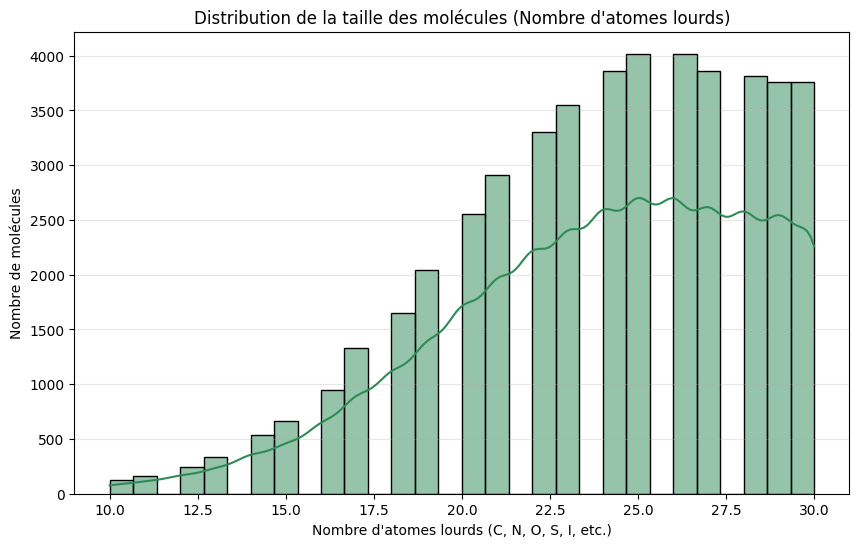

📊 Taille moyenne : 23.8 atomes
🔝 Taille max     : 30 atomes
📉 Taille min     : 10 atomes
🎯 Médiane       : 24.0 atomes


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem

def calculer_tailles(smiles_list):
    tailles = []
    for s in smiles_list:
        try:
            mol = Chem.MolFromSmiles(s)
            if mol:
                tailles.append(mol.GetNumHeavyAtoms())
        except:
            continue
    return tailles

# 1. Calcul des tailles (on peut prendre un échantillon si le df est trop gros)
print("📏 Calcul de la taille des molécules...")
tailles = calculer_tailles(df['smiles'].unique()) # .unique() pour ne pas compter 10 fois la même molécule

# 2. Affichage graphique
plt.figure(figsize=(10, 6))
sns.histplot(tailles, bins=30, kde=True, color='seagreen')

plt.title("Distribution de la taille des molécules (Nombre d'atomes lourds)")
plt.xlabel("Nombre d'atomes lourds (C, N, O, S, I, etc.)")
plt.ylabel("Nombre de molécules")
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. Statistiques descriptives
print(f"📊 Taille moyenne : {np.mean(tailles):.1f} atomes")
print(f"🔝 Taille max     : {np.max(tailles)} atomes")
print(f"📉 Taille min     : {np.min(tailles)} atomes")
print(f"🎯 Médiane       : {np.median(tailles)} atomes")

In [ ]:
import optuna
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import xgboost as xgb

## training du maitre ##

# Encodage du site
encoder = LabelEncoder()
df['Site_Encoded'] = encoder.fit_transform(df['elec_sites'])

# Parsing des charges (au cas où c'est du texte)
def parse_charges(charge_data):
    if isinstance(charge_data, str): return ast.literal_eval(charge_data)
    return charge_data

df['charges_list'] = df['elec_GCS_3_cm5'].apply(parse_charges)
charges_df = pd.DataFrame(df['charges_list'].tolist(), index=df.index).add_prefix('charge_')


# Préparation X/y pour le Maître
X_master = pd.concat([df[['Site_Encoded']], charges_df], axis=1)
y_master = df['MAA_values']

# Paramètres optimisés pour le Maître
xgb_master = xgb.XGBRegressor(
    n_estimators=1800, max_depth=11, learning_rate=0.0617, 
    tree_method='hist', n_jobs=7, random_state=42
)
xgb_master.fit(X_master, y_master)

# Distillation : Création des cibles pour l'élève
df['Teacher_MAA_Predictions'] = xgb_master.predict(X_master)


# --- 1. PRÉPARATION DES DONNÉES ---
# On fixe 10 000 sites pour l'étude (représentatif et rapide)
df_study = df.sample(10000, random_state=42).reset_index(drop=True)

def objective(trial):
    # --- A. HYPERPARAMÈTRES DE STRUCTURE (CHIMIE) ---
    rad_g = trial.suggest_int('rad_global', 1, 3)
    rad_l = trial.suggest_int('rad_local', 2, 6)
    n_bits = trial.suggest_categorical('n_bits', [2048, 4096])
    
    # --- B. HYPERPARAMÈTRES DU MODÈLE (XGBOOST) ---
    xgb_params = {
        'n_estimators': 800,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 6, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'tree_method': 'hist',
        'n_jobs': 7,
        'random_state': 42
    }

    # --- C. GÉNÉRATION DES FEATURES POUR CE TRIAL ---
    def get_fp(smiles, idx):
        mol = Chem.MolFromSmiles(smiles)
        g = AllChem.GetMorganFingerprintAsBitVect(mol, radius=rad_g, nBits=n_bits)
        l = AllChem.GetMorganFingerprintAsBitVect(mol, radius=rad_l, nBits=n_bits, fromAtoms=[int(idx)])
        return list(g) + list(l)

    X = np.array([get_fp(s, i) for s, i in zip(df_study['smiles'], df_study['elec_sites'])], dtype=np.int8)
    y = df_study['Teacher_MAA_Predictions'].values

    # --- D. VALIDATION CROISÉE (3-FOLD) ---
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model = xgb.XGBRegressor(**xgb_params)
        model.fit(X_train, y_train)
        
        preds = model.predict(X_val)
        scores.append(r2_score(y_val, preds))

    return np.mean(scores) # On optimise sur la moyenne des 3 folds

# --- 2. LANCEMENT DE L'ÉTUDE ---
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("\n" + "="*40)
print("🏆 MEILLEURS PARAMÈTRES TROUVÉS")
print("="*40) 
print(study.best_params)

[I 2026-05-10 19:26:57,946] A new study created in memory with name: no-name-7ca67eca-676f-4a29-9d89-dfed2db077c0
[I 2026-05-10 19:27:40,068] Trial 0 finished with value: 0.575027585029602 and parameters: {'rad_global': 3, 'rad_local': 6, 'n_bits': 2048, 'learning_rate': 0.02347046826117259, 'max_depth': 11, 'min_child_weight': 5, 'subsample': 0.6260970719331441, 'colsample_bytree': 0.8461623420950755}. Best is trial 0 with value: 0.575027585029602.
[I 2026-05-10 19:28:53,368] Trial 1 finished with value: 0.6333327293395996 and parameters: {'rad_global': 1, 'rad_local': 3, 'n_bits': 4096, 'learning_rate': 0.03788853802156105, 'max_depth': 12, 'min_child_weight': 5, 'subsample': 0.8208490298679689, 'colsample_bytree': 0.6253127078285893}. Best is trial 1 with value: 0.6333327293395996.
[I 2026-05-10 19:29:53,050] Trial 2 finished with value: 0.6107714176177979 and parameters: {'rad_global': 1, 'rad_local': 6, 'n_bits': 4096, 'learning_rate': 0.04511917554719937, 'max_depth': 7, 'min_chi


🏆 MEILLEURS PARAMÈTRES TROUVÉS
{'rad_global': 1, 'rad_local': 2, 'n_bits': 4096, 'learning_rate': 0.04094317855810271, 'max_depth': 10, 'min_child_weight': 2, 'subsample': 0.7886831018326952, 'colsample_bytree': 0.7829538247740371}


In [ ]:
## MODELE GLOBAL (AVEC FILTRE CHIMIQUE) PARAMETRES OPTUNA ##

import pandas as pd
import numpy as np
import xgboost as xgb
from rdkit import Chem
from rdkit.Chem import AllChem
from joblib import Parallel, delayed
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# --- 1. TES PARAMÈTRES GAGNANTS (CHAMPIONS OPTUNA) ---
BEST_RAD_G = 1
BEST_RAD_L = 2
BEST_BITS = 4096

BEST_XGB_PARAMS = {
    'n_estimators': 2000, # On pousse à 2000 pour la version finale
    'learning_rate': 0.04094,
    'max_depth': 10,
    'min_child_weight': 2,
    'subsample': 0.7886,
    'colsample_bytree': 0.7829,
    'tree_method': 'hist',
    'device': 'cpu', # Optimisé pour ton M4
    'n_jobs': 7,
    'random_state': 42
}

# --- 2. GÉNÉRATION DES FEATURES (VERSION FINALE) ---
def get_final_fp(smiles, site_idx):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            g = AllChem.GetMorganFingerprintAsBitVect(mol, radius=BEST_RAD_G, nBits=BEST_BITS)
            l = AllChem.GetMorganFingerprintAsBitVect(mol, radius=BEST_RAD_L, nBits=BEST_BITS, fromAtoms=[int(site_idx)])
            return list(g) + list(l)
    except:
        pass
    return [0] * (BEST_BITS * 2)

print(f"🚀 Génération des fingerprints sur l'ensemble du dataset ({len(df_clean)} sites)...")
# Parallélisation sur tes 7 cœurs
results = Parallel(n_jobs=7, prefer="threads", verbose=10)(
    delayed(get_final_fp)(s, idx) for s, idx in zip(df_clean['smiles'], df_clean['elec_sites'])
)

X = np.array(results, dtype=np.int8)
y = df_clean['Teacher_MAA_Predictions'].values.astype('float32')

# --- 3. SPLIT TRAIN/TEST ---
# On garde 15% pour le test final, le reste pour l'entraînement
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, range(len(X)), test_size=0.15, random_state=42
)

# --- 4. ENTRAÎNEMENT DE L'ÉLÈVE CHAMPION ---
print("🔥 Entraînement de l'Élève Champion en cours...")
final_eleve = xgb.XGBRegressor(**BEST_XGB_PARAMS)

# On utilise un petit set de validation interne pour le monitoring
X_t, X_v, y_t, y_v = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

final_eleve.fit(
    X_t, y_t,
    eval_set=[(X_v, y_v)],
    verbose=100
)

# --- 5. VERDICT FINAL ---
y_pred = final_eleve.predict(X_test)
y_true_labo = df_clean['MAA_values'].values[idx_test]

r2 = r2_score(y_test, y_pred)
r2_vs_labo = r2_score(y_true_labo, y_pred)

print("\n" + "="*60)
print("🏆 RÉSULTATS DU MODÈLE FINAL OPTIMISÉ")
print("="*60)
print(f"📈 R² (Élève vs Maître) : {r2:.4f}")
print(f"🎯 R² (Élève vs Labo)   : {r2_vs_labo:.4f}")
print(f"📉 RMSE                : {np.sqrt(mean_squared_error(y_true_labo, y_pred)):.2f}")
print("="*60)

# Sauvegarde du modèle (pour ne plus avoir à le ré-entraîner !)
import joblib
joblib.dump(final_eleve, 'model_eleve_champion.pkl')
print("💾 Modèle sauvegardé sous 'model_eleve_champion.pkl'")

🚀 Génération des fingerprints sur l'ensemble du dataset (450306 sites)...


[Parallel(n_jobs=7)]: Using backend ThreadingBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   4 tasks      | elapsed:    0.1s
[Parallel(n_jobs=7)]: Done  11 tasks      | elapsed:    0.1s
[Parallel(n_jobs=7)]: Done  18 tasks      | elapsed:    0.2s
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:    0.2s
[Parallel(n_jobs=7)]: Done  36 tasks      | elapsed:    0.2s
[Parallel(n_jobs=7)]: Done  47 tasks      | elapsed:    0.2s
[Parallel(n_jobs=7)]: Done  58 tasks      | elapsed:    0.3s
[Parallel(n_jobs=7)]: Done  71 tasks      | elapsed:    0.3s
[Parallel(n_jobs=7)]: Done  84 tasks      | elapsed:    0.3s
[Parallel(n_jobs=7)]: Done  99 tasks      | elapsed:    0.4s
[Parallel(n_jobs=7)]: Done 114 tasks      | elapsed:    0.4s
[Parallel(n_jobs=7)]: Done 131 tasks      | elapsed:    0.4s
[Parallel(n_jobs=7)]: Done 148 tasks      | elapsed:    0.5s
[Parallel(n_jobs=7)]: Done 167 tasks      | elapsed:    0.5s
[Parallel(n_jobs=7)]: Done 186 tasks      | elapsed:    0.6s
[Para

🔥 Entraînement de l'Élève Champion en cours...
[0]	validation_0-rmse:56.01876
[100]	validation_0-rmse:40.47184
[200]	validation_0-rmse:37.16978
[300]	validation_0-rmse:35.46281
[400]	validation_0-rmse:34.41605
[500]	validation_0-rmse:33.62183
[600]	validation_0-rmse:33.00490
[700]	validation_0-rmse:32.48110
[800]	validation_0-rmse:32.06420
[900]	validation_0-rmse:31.67573
[1000]	validation_0-rmse:31.37466
[1100]	validation_0-rmse:31.07576
[1200]	validation_0-rmse:30.81865
[1300]	validation_0-rmse:30.58637
[1400]	validation_0-rmse:30.38398
[1500]	validation_0-rmse:30.17740
[1600]	validation_0-rmse:29.99488
[1700]	validation_0-rmse:29.81325
[1800]	validation_0-rmse:29.66091
[1900]	validation_0-rmse:29.51116
[1999]	validation_0-rmse:29.36950

🏆 RÉSULTATS DU MODÈLE FINAL OPTIMISÉ
📈 R² (Élève vs Maître) : 0.7274
🎯 R² (Élève vs Labo)   : 0.7082
📉 RMSE                : 31.52
💾 Modèle sauvegardé sous 'model_eleve_champion.pkl'


In [3]:
## MODELE GLOBAL (SANS FILTRE CHIMIQUE) AVEC PARAMèTRES OPTUNA ##


import pandas as pd
import numpy as np
import xgboost as xgb
from rdkit import Chem
from rdkit.Chem import AllChem
from joblib import Parallel, delayed
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import ast
import joblib

# --- 1. ENTRAÎNEMENT DU MAÎTRE GLOBAL (C, N, O, S) ---
print("🎓 ÉTAPE 1 : Apprentissage du Maître sur le dataset complet...")

# Encodage et préparation des charges
encoder = LabelEncoder()
df['Site_Encoded'] = encoder.fit_transform(df['elec_sites'])

def parse_charges(charge_data):
    if isinstance(charge_data, str): return ast.literal_eval(charge_data)
    return charge_data

df['charges_list'] = df['elec_GCS_3_cm5'].apply(parse_charges)
charges_df_global = pd.DataFrame(df['charges_list'].tolist(), index=df.index).add_prefix('charge_')

X_master_global = pd.concat([df[['Site_Encoded']], charges_df_global], axis=1)
y_master_global = df['MAA_values']

# Paramètres du Maître (ceux qui marchent fort)
xgb_master_global = xgb.XGBRegressor(
    n_estimators=1800, max_depth=11, learning_rate=0.0617, 
    tree_method='hist', n_jobs=7, random_state=42
)
xgb_master_global.fit(X_master_global, y_master_global)

# Distillation : Création des cibles pour l'élève
df['Teacher_MAA_Predictions'] = xgb_master_global.predict(X_master_global)
print("✅ Cibles 'Teacher' générées.")

# --- 2. PARAMÈTRES CHAMPIONS OPTUNA POUR L'ÉLÈVE ---
BEST_RAD_G = 1
BEST_RAD_L = 2
BEST_BITS = 4096

BEST_XGB_PARAMS = {
    'n_estimators': 2000,
    'learning_rate': 0.04094,
    'max_depth': 10,
    'min_child_weight': 2,
    'subsample': 0.7886,
    'colsample_bytree': 0.7829,
    'tree_method': 'hist',
    'n_jobs': 7,
    'random_state': 42
}

# --- 3. GÉNÉRATION DES FEATURES (FINGERPRINTS) ---
def get_final_fp(smiles, site_idx):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            g = AllChem.GetMorganFingerprintAsBitVect(mol, radius=BEST_RAD_G, nBits=BEST_BITS)
            l = AllChem.GetMorganFingerprintAsBitVect(mol, radius=BEST_RAD_L, nBits=BEST_BITS, fromAtoms=[int(site_idx)])
            return list(g) + list(l)
    except:
        pass
    return [0] * (BEST_BITS * 2)

print(f"🚀 ÉTAPE 2 : Génération des fingerprints ({len(df)} sites)...")
results_global = Parallel(n_jobs=7, prefer="threads", verbose=10)(
    delayed(get_final_fp)(s, idx) for s, idx in zip(df['smiles'], df['elec_sites'])
)

X_global = np.array(results_global, dtype=np.int8)
y_global = df['Teacher_MAA_Predictions'].values.astype('float32')

# --- 4. SPLIT ET ENTRAÎNEMENT DE L'ÉLÈVE ---
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_global, y_global, range(len(X_global)), test_size=0.15, random_state=42
)

print("🔥 ÉTAPE 3 : Entraînement de l'Élève Global...")
model_global = xgb.XGBRegressor(**BEST_XGB_PARAMS)
model_global.fit(X_train, y_train, verbose=100)

# --- 5. RÉSULTATS ET SAUVEGARDE ---
y_pred = model_global.predict(X_test)
y_true_labo = df['MAA_values'].values[idx_test]

print("\n" + "="*60)
print("📊 RÉSULTATS DU MODÈLE GLOBAL (AVEC O, N, S)")
print("="*60)
print(f"📈 R² (Élève vs Maître) : {r2_score(y_test, y_pred):.4f}")
print(f"🎯 R² (Élève vs Labo)   : {r2_score(y_true_labo, y_pred):.4f}")
print(f"📉 RMSE                : {np.sqrt(mean_squared_error(y_true_labo, y_pred)):.2f}")
print("="*60)

joblib.dump(model_global, 'model_eleve_global.pkl')
print("💾 Modèle global sauvegardé.")

🎓 ÉTAPE 1 : Apprentissage du Maître sur le dataset complet...
✅ Cibles 'Teacher' générées.
🚀 ÉTAPE 2 : Génération des fingerprints (534119 sites)...


[Parallel(n_jobs=7)]: Using backend ThreadingBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=7)]: Done  11 tasks      | elapsed:    0.1s
[Parallel(n_jobs=7)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:    0.1s
[Parallel(n_jobs=7)]: Done  36 tasks      | elapsed:    0.1s
[Parallel(n_jobs=7)]: Done  47 tasks      | elapsed:    0.2s
[Parallel(n_jobs=7)]: Done  58 tasks      | elapsed:    0.2s
[Parallel(n_jobs=7)]: Done  71 tasks      | elapsed:    0.2s
[Parallel(n_jobs=7)]: Done  84 tasks      | elapsed:    0.3s
[Parallel(n_jobs=7)]: Done  99 tasks      | elapsed:    0.3s
[Parallel(n_jobs=7)]: Done 114 tasks      | elapsed:    0.4s
[Parallel(n_jobs=7)]: Done 131 tasks      | elapsed:    0.4s
[Parallel(n_jobs=7)]: Done 148 tasks      | elapsed:    0.4s
[Parallel(n_jobs=7)]: Done 167 tasks      | elapsed:    0.5s
[Parallel(n_jobs=7)]: Done 186 tasks      | elapsed:    0.6s
[Para

🔥 ÉTAPE 3 : Entraînement de l'Élève Global...

📊 RÉSULTATS DU MODÈLE GLOBAL (AVEC O, N, S)
📈 R² (Élève vs Maître) : 0.8141
🎯 R² (Élève vs Labo)   : 0.7932
📉 RMSE                : 32.64
💾 Modèle global sauvegardé.
